# 02 Train FiLM AE FINAL v2 PyTorch

This notebook trains the FiLM-conditioned autoencoder on the Alibaba-archive dataset artifacts created in notebook 01. The autoencoder remains the core anomaly detector; this stage learns the reconstruction model, saves the checkpoint and scalers, and fits the reconstruction-error threshold on the validation split.


In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from container_ad_pipeline.config import PipelineConfig, ensure_pipeline_directories
from container_ad_pipeline.dataset import build_dataset_from_raw_archives, load_dataset_bundle
from container_ad_pipeline.train import (
    fit_threshold_on_validation,
    predict_reconstructions,
    reconstruction_scores,
    select_split,
    train_film_autoencoder,
    transform_inputs,
)

pd.set_option("display.max_columns", 200)
config = PipelineConfig()
ensure_pipeline_directories(config)

config.dataset.max_container_meta_files = 10
config.dataset.max_container_usage_files = 10
config.dataset.max_machine_meta_files = None
config.dataset.max_machine_usage_files = 10
config.dataset.max_usage_rows = 20_000_000
config.dataset.max_machine_usage_rows = 20_000_000
config.dataset.max_containers = 1000
config.dataset.chunksize = 5_000
config.train.device = "cuda"

if not (config.paths.processed_dir / "X_all.npy").exists():
    build_dataset_from_raw_archives(config.paths, config.dataset, config.paths.processed_dir)

bundle = load_dataset_bundle(config.paths.processed_dir)
print(bundle.X.shape, bundle.C.shape)

config.train.epochs = 30
config.train.patience = 8
config.train.batch_size = 128


(163140, 24, 8) (163140, 17)


## Train The FiLM Autoencoder

Training, checkpointing, and threshold metadata are handled by the Python modules. The notebook stays focused on experiment control, artifact inspection, and plotting.


In [2]:
artifacts = train_film_autoencoder(
    bundle=bundle,
    train_config=config.train,
    checkpoint_path=config.paths.checkpoint_path,
    x_scaler_path=config.paths.x_scaler_path,
    c_scaler_path=config.paths.c_scaler_path,
    detector_meta_json=config.paths.detector_meta_json,
    detector_meta_joblib=config.paths.detector_meta_joblib,
)

history_df = artifacts.history.copy()
display(history_df.tail())
display(pd.Series(artifacts.detector_meta, name="detector_meta"))


,epoch,train_loss,val_loss
25,26,0.215326,0.231282
26,27,0.211228,0.225573
27,28,0.210720,0.222005
28,29,0.206533,0.218891
29,30,0.204535,0.223567


threshold                     5.500068
threshold_quantile               0.995
window_size                         24
n_features                           8
context_dim                         17
score_mode            mean_feature_mse
num_train_windows               114198
num_val_windows                  24471
best_val_loss                 0.218891
Name: detector_meta, dtype: object

## Plot Training And Validation Loss

The loss curves provide a compact research view of optimization stability and generalization on the held-out validation split.


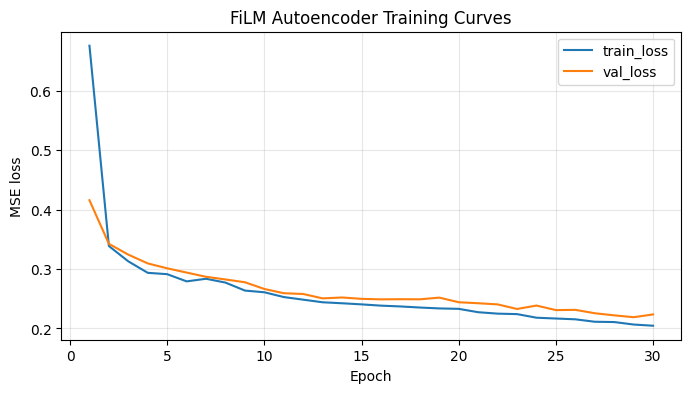

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("FiLM Autoencoder Training Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Fit And Inspect The Validation Threshold

The anomaly threshold is derived from the validation reconstruction scores. GPT is not used here; the autoencoder alone defines the anomaly score and the crossing criterion.


saved_threshold                                                  5.500068
recomputed_threshold                                             5.500068
threshold_quantile                                                  0.995
num_val_windows                                                     24471
checkpoint_path         C:\Users\kaspe\Desktop\Project\project\artifac...
x_scaler_path           C:\Users\kaspe\Desktop\Project\project\artifac...
c_scaler_path           C:\Users\kaspe\Desktop\Project\project\artifac...
Name: value, dtype: object

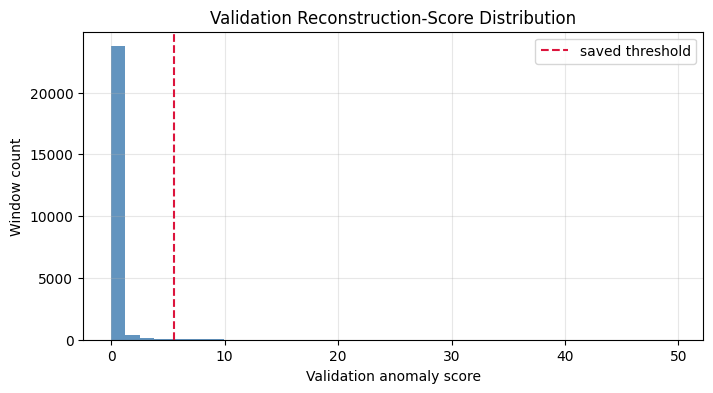

In [4]:
X_val, C_val, val_meta = select_split(bundle, "val")
X_val_scaled, C_val_scaled = transform_inputs(X_val, C_val, artifacts.x_scaler, artifacts.c_scaler)
X_val_pred = predict_reconstructions(artifacts.model, X_val_scaled, C_val_scaled)
val_scores = reconstruction_scores(X_val_scaled, X_val_pred)
recomputed_threshold = fit_threshold_on_validation(val_scores, config.train.threshold_quantile)

threshold_summary = pd.Series(
    {
        "saved_threshold": artifacts.detector_meta["threshold"],
        "recomputed_threshold": float(recomputed_threshold),
        "threshold_quantile": config.train.threshold_quantile,
        "num_val_windows": len(val_meta),
        "checkpoint_path": str(config.paths.checkpoint_path),
        "x_scaler_path": str(config.paths.x_scaler_path),
        "c_scaler_path": str(config.paths.c_scaler_path),
    },
    name="value",
)
display(threshold_summary)

plt.figure(figsize=(8, 4))
plt.hist(val_scores, bins=40, alpha=0.85, color="steelblue")
plt.axvline(artifacts.detector_meta["threshold"], color="crimson", linestyle="--", label="saved threshold")
plt.xlabel("Validation anomaly score")
plt.ylabel("Window count")
plt.title("Validation Reconstruction-Score Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Saved Training Artifacts

The checkpoint, scalers, and detector metadata are written to the artifact directory for reuse by the evaluation and GPT adjudication notebooks.


In [5]:
artifact_paths = pd.Series(
    {
        "checkpoint_path": str(config.paths.checkpoint_path),
        "x_scaler_path": str(config.paths.x_scaler_path),
        "c_scaler_path": str(config.paths.c_scaler_path),
        "detector_meta_json": str(config.paths.detector_meta_json),
        "detector_meta_joblib": str(config.paths.detector_meta_joblib),
    },
    name="artifact_path",
)
display(artifact_paths)

display(pd.Series(joblib.load(config.paths.detector_meta_joblib), name="saved_detector_meta"))


checkpoint_path         C:\Users\kaspe\Desktop\Project\project\artifac...
x_scaler_path           C:\Users\kaspe\Desktop\Project\project\artifac...
c_scaler_path           C:\Users\kaspe\Desktop\Project\project\artifac...
detector_meta_json      C:\Users\kaspe\Desktop\Project\project\artifac...
detector_meta_joblib    C:\Users\kaspe\Desktop\Project\project\artifac...
Name: artifact_path, dtype: str

threshold                     5.500068
threshold_quantile               0.995
window_size                         24
n_features                           8
context_dim                         17
score_mode            mean_feature_mse
num_train_windows               114198
num_val_windows                  24471
best_val_loss                 0.218891
Name: saved_detector_meta, dtype: object